# 1. Import Libraries

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/new_insurance_data (1).csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


# 3. Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

# EDA - Exploratory Data Analysis
   1. Null values
   2. Duplicate values
   3. Outliers
   4. Label encoding
   

In [ ]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
# Dropping null values
# df.dropna(inplace = True) #inplace = True : permanently makes the changes

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
# Filling the missing values, mode for object and mean for numerical

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna(df[col].mode()[0])  # [0] represent first mode value
  else:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Dropping duplicated values
# df.drop_duplicates(inplace = Ture)

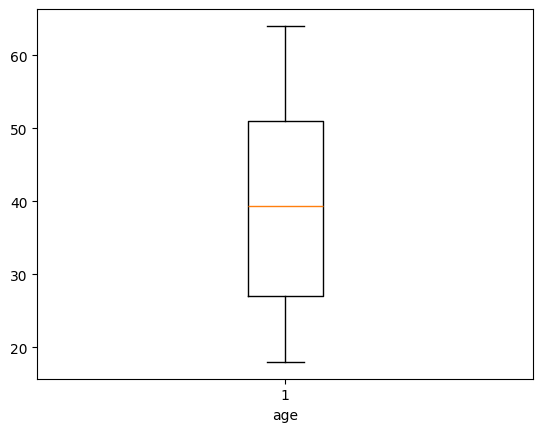

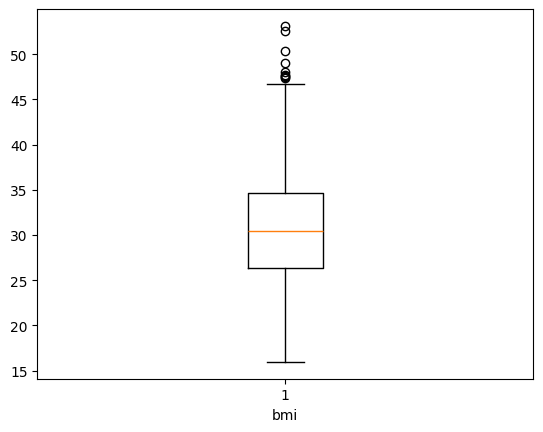

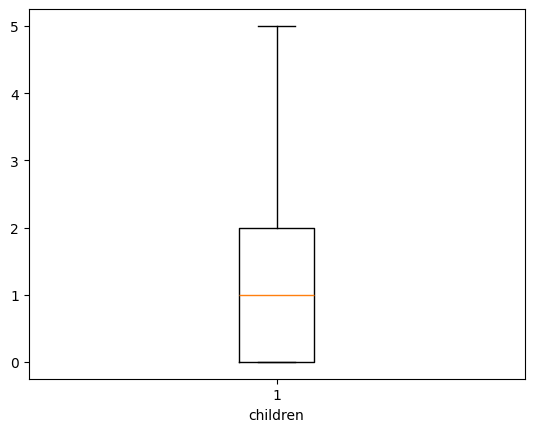

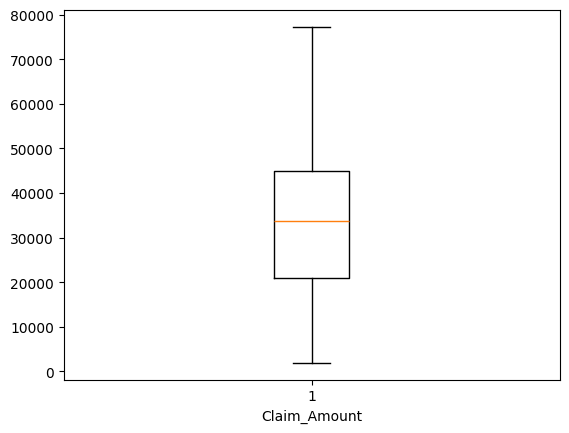

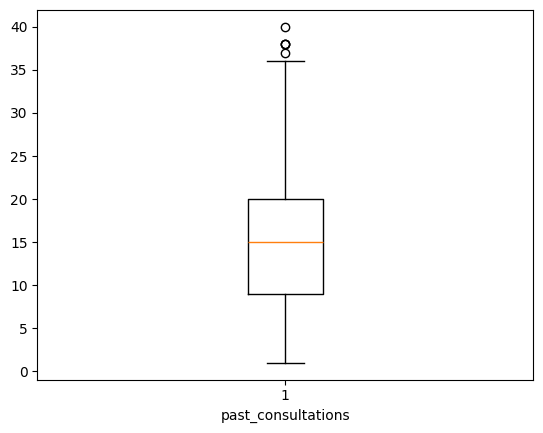

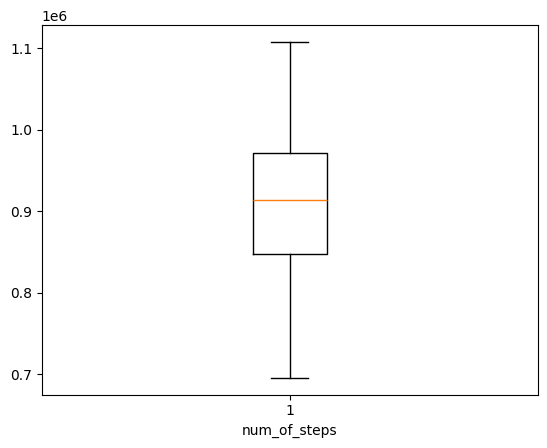

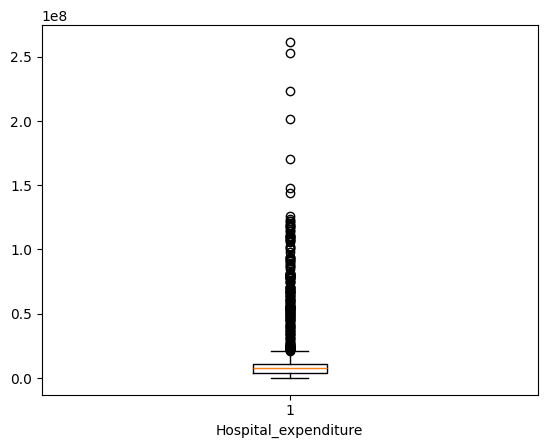

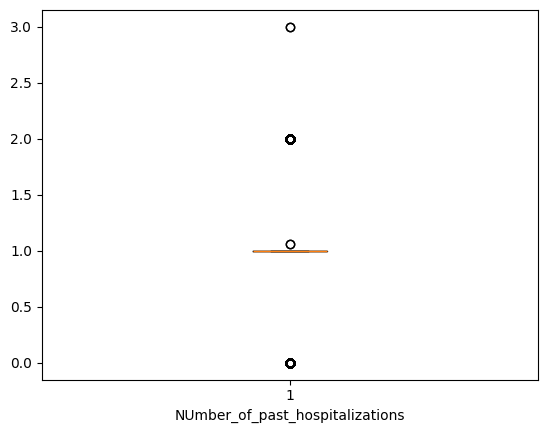

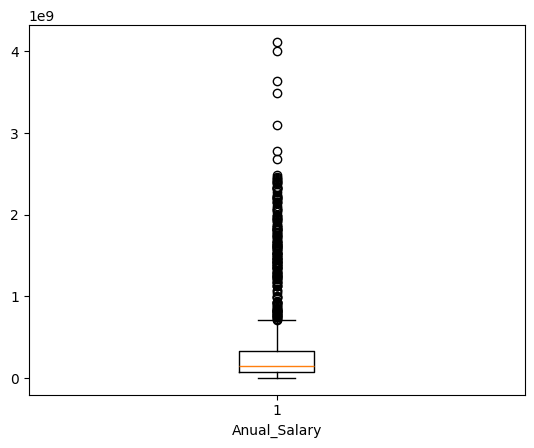

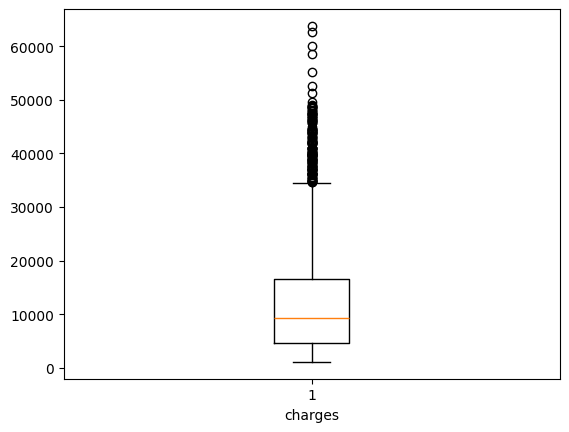

In [ ]:
# Outliers

for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

# if no box is visible, avoid doing anything to that column because majority of the values are extreme
# so dropping outliers from this column might drop the whole column itself

In [ ]:
# Outlier removal: charges is target(dependent)

out_list=['bmi', 'past_consultations', 'Hospital_expenditure', 'Anual_Salary']

for col in out_list:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  LB = Q1 - 1.5*IQR
  UB = Q3 + 1.5*IQR

  df = df[(df[col] >= LB) & df[col] <= UB]
  # filtering data that is within the range comparing it with LB and UB and reassigning
  # it back to df for removal


In [ ]:
# Label Encoding: converting object to numerical

from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()  # instance, used to convert text to numbers

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = LE.fit_transform(df[col])



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   sex                              1338 non-null   int64  
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   int64  
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   num_of_steps                     1338 non-null   float64
 8   Hospital_expenditure             1338 non-null   float64
 9   NUmber_of_past_hospitalizations  1338 non-null   float64
 10  Anual_Salary                     1338 non-null   float64
 11  region                           1338 non-null   int64  
 12  charges             

# Model Training

   1. splitting the data into x(feature), y(target)
   2. splitting in terms of training and testing data
   3. model initialization
   4. train the model
   5. prediction

In [ ]:
x = df.iloc[:,:-1] # getting all rows and cols except charges
# x = df.drop('Charges')
y = df['charges']

In [ ]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2


In [ ]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1333,55135.40209
1334,58571.07448
1335,60021.39897
1336,62592.87309


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.80, random_state =0)
# splits the dataset into training(80%) and testing data(20%)
# x-train & test: Features(input data) for trainig and testing
# y-train & test: Target(output data) for traning and testing

In [ ]:
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
621,45.0,1,24.035,2.0,0,14184.67664,22.0,890983.0,6.512320e+06,1.0,7.564824e+07,0
194,20.0,0,31.790,2.0,0,43988.96850,11.0,811187.0,2.418227e+06,1.0,1.074332e+08,2
240,25.0,0,22.515,1.0,0,22987.02313,20.0,813854.0,4.956462e+06,1.0,9.120422e+07,1
1168,40.0,0,41.420,1.0,0,27534.30280,15.0,1031312.0,2.543862e+07,2.0,8.690106e+08,1
1192,25.0,0,30.200,0.0,1,38838.01180,19.0,1049108.0,4.202504e+07,2.0,1.159497e+09,3
...,...,...,...,...,...,...,...,...,...,...,...,...
763,54.0,0,32.680,0.0,0,18094.64393,20.0,935382.0,1.052415e+07,1.0,1.393229e+08,0
835,58.0,0,39.050,0.0,0,30333.00033,21.0,935611.0,3.445156e+06,1.0,1.422656e+08,2
1216,29.0,1,34.400,0.0,1,24969.29952,25.0,1052642.0,4.883718e+07,2.0,1.377813e+09,3
559,44.0,1,30.690,2.0,0,33330.50185,21.0,885629.0,6.868865e+06,1.0,7.559974e+07,2


In [ ]:
x_test

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
578,44.0,1,32.015,2.0,0,31762.06218,18.0,898402.0,1.584179e+07,1.0,1.388538e+08,1
610,47.0,0,24.320,0.0,0,12207.16184,7.0,914552.0,3.474461e+06,1.0,1.607867e+08,0
569,39.0,0,23.275,3.0,0,32800.38085,19.0,898034.0,7.900849e+06,1.0,1.314127e+08,0
1034,24.0,1,29.830,0.0,1,35155.45242,17.0,979075.0,1.226416e+07,1.0,3.674079e+08,0
198,28.0,0,25.800,0.0,0,12942.46187,14.0,790605.0,3.101092e+06,1.0,5.291157e+07,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1084,48.0,1,24.420,0.0,1,53279.99334,18.0,1005887.0,1.595273e+07,1.0,4.545239e+08,2
726,54.0,1,30.210,0.0,0,28219.04718,6.0,934704.0,6.333271e+06,1.0,1.094440e+08,1
1132,26.0,0,29.640,4.0,0,47575.32907,23.0,1002032.0,1.899911e+07,2.0,6.848551e+08,0
725,55.0,1,38.280,0.0,0,11235.87207,20.0,913921.0,9.429019e+06,1.0,1.889853e+08,2


In [ ]:
y_train

,charges
621,8604.48365
194,3056.38810
240,3594.17085
1168,28476.73499
1192,33900.65300
...,...
763,10923.93320
835,11856.41150
1216,36197.69900
559,7731.42710


In [ ]:
y_test

,charges
578,8116.26885
610,8534.67180
569,7986.47525
1034,18648.42170
198,3161.45400
...,...
1084,21223.67580
726,10231.49990
1132,24671.66334
725,10226.28420


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

# 6. Evaluation

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([ 9.31112447e+03,  1.00986007e+04,  8.80365972e+03,  1.94237077e+04,
        2.52844166e+03,  1.41282741e+04, -1.40222647e+03,  3.90983019e+04,
        3.60275986e+04,  4.79642454e+04,  8.01284786e+03,  2.09512234e+04,
        4.04535404e+04,  5.86343651e+03,  1.27815446e+04,  1.29535657e+04,
        1.15101353e+04,  2.47854300e+03,  2.65590024e+04,  1.76160262e+04,
        1.46066675e+04,  8.20081319e+03,  2.07052140e+04,  1.17860948e+04,
        2.21592051e+04,  5.34846505e+03,  4.22651845e+04,  6.51130830e+03,
        2.81172833e+03,  7.96703324e+03,  8.97819223e+01,  1.89138650e+04,
        1.07128039e+04,  7.80466792e+02,  1.88728167e+04,  1.90131270e+04,
        2.17217763e+04, -9.09177966e+02,  9.74944292e+03,  4.05430029e+04,
        1.17838413e+04,  1.31223179e+03,  9.70424698e+03,  8.49744351e+01,
        2.96902724e+03,  1.76974785e+04,  3.81090792e+03,  4.72983162e+04,
        3.23969834e+04,  1.10322587e+04,  2.79705624e+04,  3.23802706e+04,
       -5.09697843e+02,  

In [ ]:
results = pd.DataFrame(columns=['Actual_values', 'Predicted_values'])
results['Actual_values'] = y_test
results['Predicted_values'] = y_pred
results

,Actual_values,Predicted_values
578,8116.26885,9311.124474
610,8534.67180,10098.600651
569,7986.47525,8803.659720
1034,18648.42170,19423.707742
198,3161.45400,2528.441657
...,...,...
1084,21223.67580,21885.126489
726,10231.49990,10842.304043
1132,24671.66334,21454.604343
725,10226.28420,11013.627302


In [ ]:
from sklearn.metrics import *

res=r2_score(y_test,y_pred)
res*100

98.67417669381797

# 7. Conclusion

<function matplotlib.pyplot.show(close=None, block=None)>

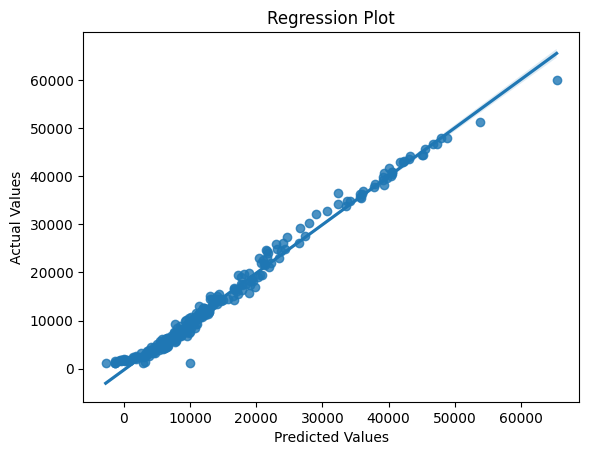

In [ ]:
sns.regplot(x=y_pred, y =y_test)
plt.title('Regression Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show